In [5]:
!pip install insightface onnxruntime opencv-python torch torchvision matplotlib scikit-learn

  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
   ---------------------------------------- 0.0/762.2 kB ? eta -:--:--
   ---------------------------------------- 762.2/762.2 kB 6.6 MB/s  0:00:00
   ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
   ---------------------- ----------------- 7.3/13.0 MB 35.8 MB/s eta 0:00:01
   ---------------------------------------- 13.0/13.0 MB 35.1 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------------------------------- -- 7.6/8.2 MB 37.5 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 37.1 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 15.4 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 k


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import insightface
from insightface.model_zoo import get_model
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [2]:
class DepthwiseSeparable(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride, 1, groups=in_ch, bias=False)
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.PReLU(out_ch)

    def forward(self, x):
        x = self.relu(self.bn1(self.dw(x)))
        return self.relu(self.bn2(self.pw(x)))

class Bottleneck(nn.Module):
    def __init__(self, in_ch, out_ch, stride, expand):
        super().__init__()
        mid = in_ch * expand
        self.use_res = (stride == 1 and in_ch == out_ch)
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.BatchNorm2d(mid),
            nn.PReLU(mid),
            nn.Conv2d(mid, mid, 3, stride, 1, groups=mid, bias=False),
            nn.BatchNorm2d(mid),
            nn.PReLU(mid),
            nn.Conv2d(mid, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )

    def forward(self, x):
        out = self.block(x)
        return out + x if self.use_res else out

In [3]:
class MobileFaceNetBackbone(nn.Module):
    def __init__(self, embedding_size=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.PReLU(64),
            DepthwiseSeparable(64, 64),
            Bottleneck(64, 64,  stride=2, expand=2),
            Bottleneck(64, 64,  stride=1, expand=2),
            Bottleneck(64, 64,  stride=1, expand=2),
            Bottleneck(64, 64,  stride=1, expand=2),
            Bottleneck(64, 128, stride=2, expand=4),
            Bottleneck(128, 128, stride=1, expand=2),
            Bottleneck(128, 128, stride=1, expand=2),
            Bottleneck(128, 128, stride=1, expand=2),
            Bottleneck(128, 128, stride=1, expand=2),
            Bottleneck(128, 128, stride=1, expand=2),
            Bottleneck(128, 128, stride=1, expand=2),
            Bottleneck(128, 256, stride=2, expand=4),
            Bottleneck(256, 256, stride=1, expand=2),
            Bottleneck(256, 256, stride=1, expand=2),
            nn.Conv2d(256, 512, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.PReLU(512),
        )
        # Global Depthwise Conv (GDConv)
        self.gdconv = nn.Conv2d(512, 512, 7, groups=512, bias=False)
        self.bn_gd  = nn.BatchNorm2d(512)
        self.fc     = nn.Linear(512, embedding_size)
        self.bn_fc  = nn.BatchNorm1d(embedding_size)

    def forward(self, x):
        x = self.features(x)
        x = self.bn_gd(self.gdconv(x))
        x = x.view(x.size(0), -1)
        x = self.bn_fc(self.fc(x))
        return x

backbone = MobileFaceNetBackbone(embedding_size=128).to(device)
print("Backbone MobileFaceNet creado")
print(f"Parámetros totales: {sum(p.numel() for p in backbone.parameters()):,}")

Backbone MobileFaceNet creado
Parámetros totales: 1,521,792


In [4]:
class MobileFaceNetClassifier(nn.Module):
    def __init__(self, backbone, num_classes=40, freeze_backbone=True):
        super().__init__()
        self.backbone = backbone

        # Congelar backbone en fase 1
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.PReLU(64),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        embedding = self.backbone(x)
        return self.classifier(embedding)

    def unfreeze_last_n(self, n=3):
        """Descongela las últimas n capas del backbone para fine-tuning"""
        layers = list(self.backbone.features.children())
        for layer in layers[-n:]:
            for param in layer.parameters():
                param.requires_grad = True
        print(f"Últimas {n} capas del backbone descongeladas")

    def unfreeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("Backbone completamente descongelado")

model = MobileFaceNetClassifier(backbone, num_classes=40, freeze_backbone=True).to(device)
print(model)

MobileFaceNetClassifier(
  (backbone): MobileFaceNetBackbone(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): PReLU(num_parameters=64)
      (3): DepthwiseSeparable(
        (dw): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (pw): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): PReLU(num_parameters=64)
      )
      (4): Bottleneck(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, tr

In [7]:
class ORLDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        EXTENSIONES = ('.pgm', '.png', '.jpg', '.jpeg', '.bmp', '.gif')

        sujetos = sorted([s for s in os.listdir(root_dir) 
                          if os.path.isdir(os.path.join(root_dir, s))])
        
        for label, subject in enumerate(sujetos):
            subject_path = os.path.join(root_dir, subject)
            images = sorted([f for f in os.listdir(subject_path)
                             if f.lower().endswith(EXTENSIONES)])
            for img_name in images:
                self.samples.append((os.path.join(subject_path, img_name), label))

        print(f"  → {root_dir}: {len(sujetos)} sujetos, {len(self.samples)} imágenes cargadas")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Transforms para cada combinación
transform_base = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_aug = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


PATHS = {
    'LR_x2':    ('dataset/Training_LR_escala2/',                  'dataset/Testing_LR_CLAHE_escala2/'),
    'LR_x4':    ('dataset/Training_LR_escala4/',                  'dataset/Testing_LR_CLAHE_escala4/'),
    'CLAHE_x2': ('dataset/CLAHE/Training_CLAHE_escala2/',         'dataset/CLAHE/Testing_CLAHE_escala2/'),
    'CLAHE_x4': ('dataset/CLAHE/Training_CLAHE_escala4/',         'dataset/CLAHE/Testing_CLAHE_escala4/'),
    'SRCNN_x2': ('dataset/Super_resolution/Training_SR_escala2/', 'dataset/Super_resolution/Testing_SR_escala2/'),
    'SRCNN_x4': ('dataset/Super_resolution/Training_SR_escala4/', 'dataset/Super_resolution/Testing_SR_escala4/'),
}

In [8]:
for nombre, (ruta_train, ruta_test) in PATHS.items():
    sujetos_train = [s for s in os.listdir(ruta_train) if os.path.isdir(os.path.join(ruta_train, s))]
    sujetos_test  = [s for s in os.listdir(ruta_test)  if os.path.isdir(os.path.join(ruta_test,  s))]
    total_train   = sum(len(os.listdir(os.path.join(ruta_train, s))) for s in sujetos_train)
    total_test    = sum(len(os.listdir(os.path.join(ruta_test,  s))) for s in sujetos_test)
    print(f"{nombre:<12} | Train: {len(sujetos_train)} sujetos, {total_train} imgs | Test: {len(sujetos_test)} sujetos, {total_test} imgs")

LR_x2        | Train: 40 sujetos, 360 imgs | Test: 40 sujetos, 40 imgs
LR_x4        | Train: 40 sujetos, 360 imgs | Test: 40 sujetos, 40 imgs
CLAHE_x2     | Train: 40 sujetos, 360 imgs | Test: 40 sujetos, 40 imgs
CLAHE_x4     | Train: 40 sujetos, 360 imgs | Test: 40 sujetos, 40 imgs
SRCNN_x2     | Train: 40 sujetos, 360 imgs | Test: 40 sujetos, 40 imgs
SRCNN_x4     | Train: 40 sujetos, 360 imgs | Test: 40 sujetos, 40 imgs


In [9]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, phase_name="Fase1", verbose=False):
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0

    for epoch in range(epochs):
        # --- Entrenamiento ---
        model.train()
        train_loss, train_preds, train_labels = 0, [], []

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(outputs.argmax(1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        # --- Validación ---
        model.eval()
        val_loss, val_preds, val_labels = 0, [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_preds.extend(outputs.argmax(1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        # Métricas
        t_loss = train_loss / len(train_loader)
        v_loss = val_loss  / len(val_loader)
        t_acc  = accuracy_score(train_labels, train_preds)
        v_acc  = accuracy_score(val_labels,   val_preds)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        scheduler.step(v_loss)

        # Obtener lr actual
        current_lr = optimizer.param_groups[0]['lr']

        if best_acc < v_acc:
            best_acc = v_acc
            torch.save(model.state_dict(), f'mobilefacenet_{phase_name}_best.pth')
            saved = " ✓ guardado"
        else:
            saved = ""

        # Verbose por época
        if verbose:
            print(f"{epoch+1:<8} {t_loss:<12.4f} {v_loss:<12.4f} {t_acc:<12.4f} {v_acc:<10.4f} {current_lr:.2e}{saved}")

    print(f"\nMejor accuracy validación [{phase_name}]: {best_acc:.4f}")
    return history

In [12]:
resultados = {}

for nombre, (ruta_train, ruta_test) in PATHS.items():
    print(f"\n{'='*50}")
    print(f"Entrenando con: {nombre.upper()}")
    print(f"  Train: {ruta_train}")
    print(f"  Test:  {ruta_test}")
    print(f"{'='*50}")

    train_ds = ORLDataset(ruta_train, transform=transform_aug)
    val_ds   = ORLDataset(ruta_test,  transform=transform_base)

    print(f"Imágenes train: {len(train_ds)} | Imágenes val: {len(val_ds)}")

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0, drop_last=False)

    backbone_i = MobileFaceNetBackbone(embedding_size=128).to(device)
    model_i    = MobileFaceNetClassifier(backbone_i, num_classes=40, freeze_backbone=True).to(device)

    # Fase 1 — Transfer Learning (backbone congelado)
    print("\n--- FASE 1: Transfer Learning — Backbone congelado ---")
    print(f"{'Época':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<12} {'Val Acc':<10} {'LR'}")
    print("-" * 65)
    h1 = train_model(model_i, train_loader, val_loader,
                     epochs=30, lr=1e-3,
                     phase_name=f"{nombre}_fase1",
                     verbose=True)

    # Fase 2 — Fine-tuning (últimas 3 capas descongeladas)
    print("\n--- FASE 2: Fine-tuning — Últimas 3 capas descongeladas ---")
    model_i.unfreeze_last_n(n=3)
    print(f"{'Época':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<12} {'Val Acc':<10} {'LR'}")
    print("-" * 65)
    h2 = train_model(model_i, train_loader, val_loader,
                     epochs=30, lr=1e-4,
                     phase_name=f"{nombre}_fase2",
                     verbose=True)

    # Fase 3 — Fine-tuning completo (backbone completo descongelado)
    print("\n--- FASE 3: Fine-tuning completo — Backbone descongelado ---")
    model_i.unfreeze_all()
    print(f"{'Época':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<12} {'Val Acc':<10} {'LR'}")
    print("-" * 65)
    h3 = train_model(model_i, train_loader, val_loader,
                     epochs=20, lr=1e-5,
                     phase_name=f"{nombre}_fase3",
                     verbose=True)

    # Combinar historial
    history_combined = {
        'train_loss': h1['train_loss'] + h2['train_loss'] + h3['train_loss'],
        'val_loss':   h1['val_loss']   + h2['val_loss']   + h3['val_loss'],
        'train_acc':  h1['train_acc']  + h2['train_acc']  + h3['train_acc'],
        'val_acc':    h1['val_acc']    + h2['val_acc']    + h3['val_acc'],
    }
    resultados[nombre] = history_combined


Entrenando con: LR_X2
  Train: dataset/Training_LR_escala2/
  Test:  dataset/Testing_LR_CLAHE_escala2/
  → dataset/Training_LR_escala2/: 40 sujetos, 360 imágenes cargadas
  → dataset/Testing_LR_CLAHE_escala2/: 40 sujetos, 40 imágenes cargadas
Imágenes train: 360 | Imágenes val: 40

--- FASE 1: Transfer Learning — Backbone congelado ---
Época    Train Loss   Val Loss     Train Acc    Val Acc    LR
-----------------------------------------------------------------
1        3.7414       3.7197       0.0194       0.0250     1.00e-03 ✓ guardado
2        3.6325       3.6376       0.0528       0.0000     1.00e-03
3        3.5236       3.6002       0.0861       0.0000     1.00e-03
4        3.5193       3.5598       0.0778       0.0000     1.00e-03
5        3.4610       3.5140       0.0778       0.0250     1.00e-03
6        3.3333       3.4865       0.1194       0.0500     1.00e-03 ✓ guardado
7        3.2937       3.4472       0.1528       0.0000     1.00e-03
8        3.2481       3.4172       

In [13]:
print(f"\n{'='*55}")
print(f"{'Combinación':<20} {'Best Val Acc':>12} {'Best Val Loss':>14}")
print(f"{'='*55}")

for nombre, h in resultados.items():
    best_acc  = max(h['val_acc'])
    best_loss = min(h['val_loss'])
    print(f"{nombre:<20} {best_acc:>12.4f} {best_loss:>14.4f}")

print(f"{'='*55}")


Combinación          Best Val Acc  Best Val Loss
LR_x2                      0.6500         1.8979
LR_x4                      0.3500         2.7299
CLAHE_x2                   0.6000         1.9573
CLAHE_x4                   0.3750         2.3844
SRCNN_x2                   0.4250         2.0324
SRCNN_x4                   0.6000         1.8411


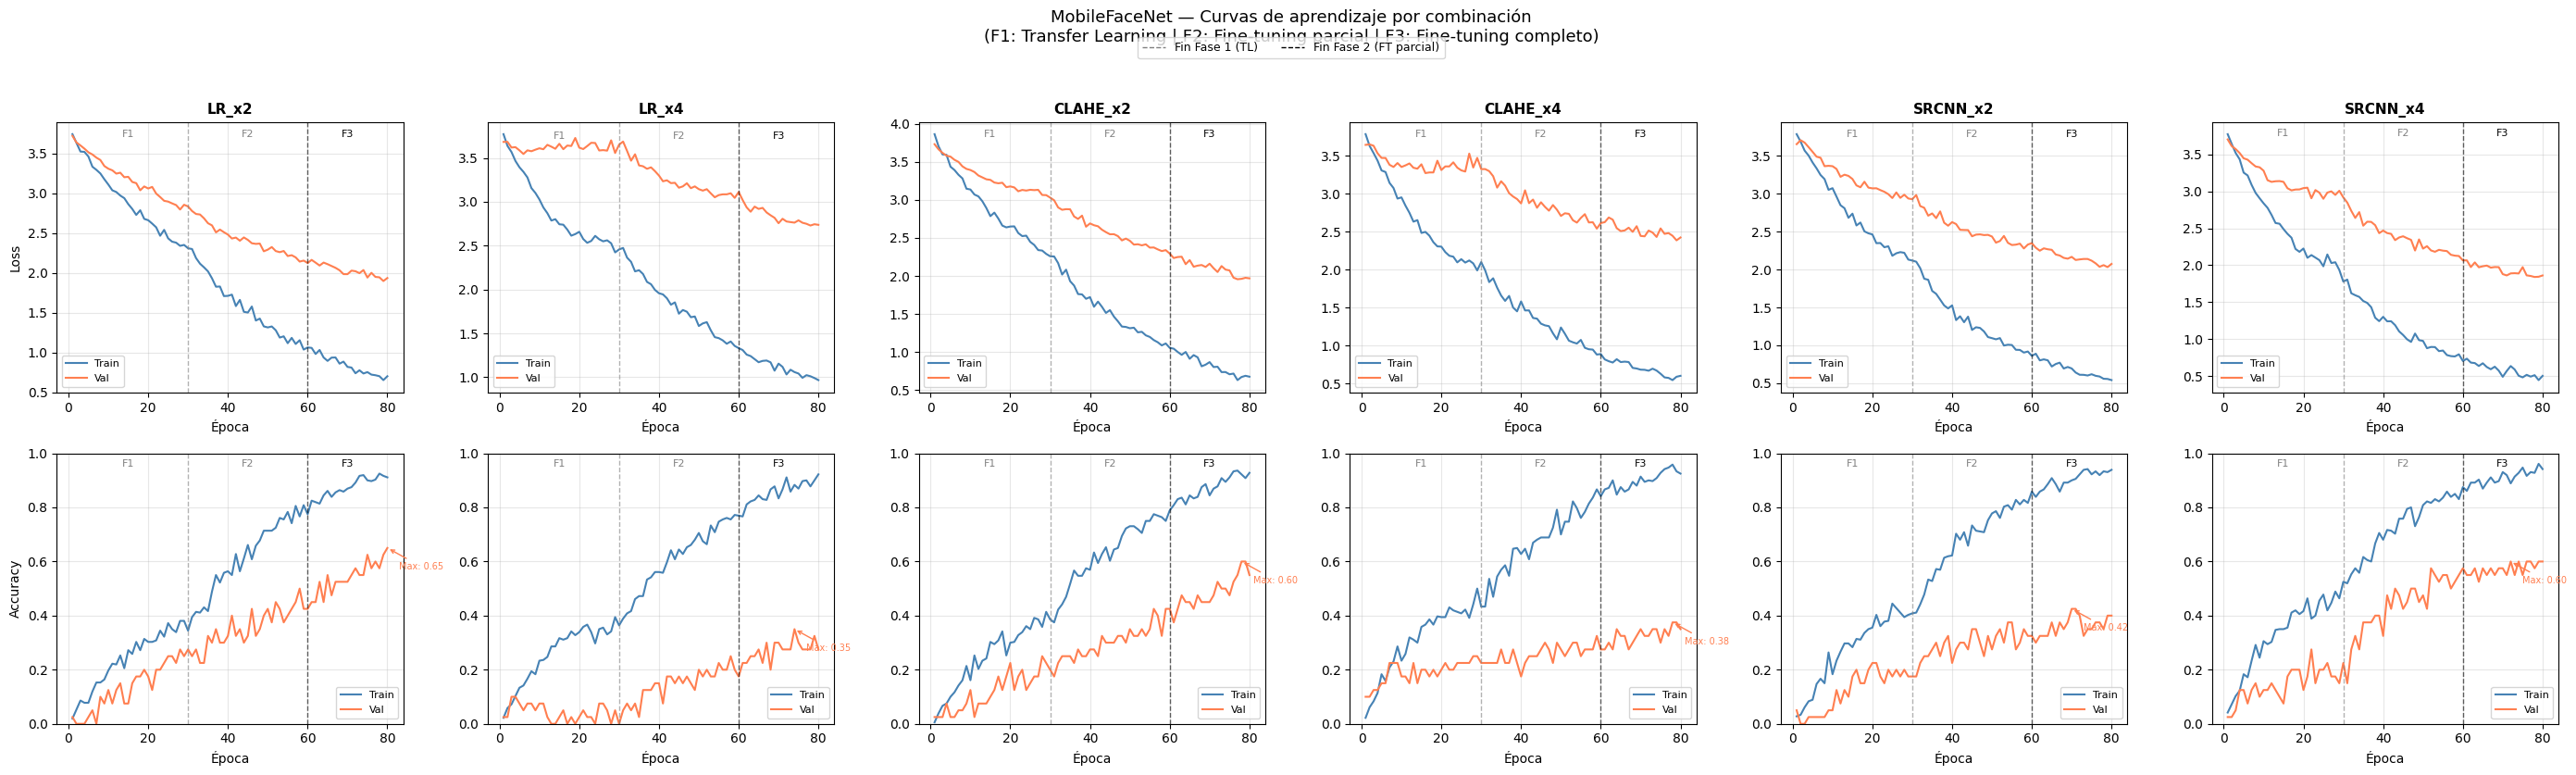

Curvas guardadas en mobilefacenet_curvas.png


In [14]:
def plot_curvas(resultados):
    fig, axes = plt.subplots(2, 6, figsize=(28, 8))
    nombres = list(resultados.keys())

    for i, nombre in enumerate(nombres):
        h = resultados[nombre]
        epochs = range(1, len(h['train_loss']) + 1)

        # Líneas divisoras de fases
        fase1_end = 30
        fase2_end = 60

        # --- Loss ---
        axes[0, i].plot(epochs, h['train_loss'], label='Train', color='steelblue',  linewidth=1.5)
        axes[0, i].plot(epochs, h['val_loss'],   label='Val',   color='coral',      linewidth=1.5)
        axes[0, i].axvline(x=fase1_end, color='gray',  linestyle='--', alpha=0.6, linewidth=1)
        axes[0, i].axvline(x=fase2_end, color='black', linestyle='--', alpha=0.6, linewidth=1)
        axes[0, i].set_title(f'{nombre}', fontsize=11, fontweight='bold')
        axes[0, i].set_ylabel('Loss' if i == 0 else '')
        axes[0, i].set_xlabel('Época')
        axes[0, i].legend(fontsize=8)
        axes[0, i].grid(True, alpha=0.3)

        # Etiquetas de fase
        axes[0, i].text(15,  axes[0, i].get_ylim()[1]*0.95, 'F1', fontsize=8, color='gray',  ha='center')
        axes[0, i].text(45,  axes[0, i].get_ylim()[1]*0.95, 'F2', fontsize=8, color='gray',  ha='center')
        axes[0, i].text(70,  axes[0, i].get_ylim()[1]*0.95, 'F3', fontsize=8, color='black', ha='center')

        # --- Accuracy ---
        axes[1, i].plot(epochs, h['train_acc'], label='Train', color='steelblue',  linewidth=1.5)
        axes[1, i].plot(epochs, h['val_acc'],   label='Val',   color='coral',      linewidth=1.5)
        axes[1, i].axvline(x=fase1_end, color='gray',  linestyle='--', alpha=0.6, linewidth=1)
        axes[1, i].axvline(x=fase2_end, color='black', linestyle='--', alpha=0.6, linewidth=1)
        axes[1, i].set_ylabel('Accuracy' if i == 0 else '')
        axes[1, i].set_xlabel('Época')
        axes[1, i].set_ylim(0, 1)
        axes[1, i].legend(fontsize=8)
        axes[1, i].grid(True, alpha=0.3)

        # Etiquetas de fase
        axes[1, i].text(15, 0.95, 'F1', fontsize=8, color='gray',  ha='center')
        axes[1, i].text(45, 0.95, 'F2', fontsize=8, color='gray',  ha='center')
        axes[1, i].text(70, 0.95, 'F3', fontsize=8, color='black', ha='center')

        # Mejor val acc como anotación
        best_acc   = max(h['val_acc'])
        best_epoch = h['val_acc'].index(best_acc) + 1
        axes[1, i].annotate(f'Max: {best_acc:.2f}',
                            xy=(best_epoch, best_acc),
                            xytext=(best_epoch + 3, best_acc - 0.08),
                            fontsize=7, color='coral',
                            arrowprops=dict(arrowstyle='->', color='coral', lw=1))

    # Leyenda de fases
    from matplotlib.lines import Line2D
    leyenda = [
        Line2D([0], [0], color='gray',  linestyle='--', lw=1, label='Fin Fase 1 (TL)'),
        Line2D([0], [0], color='black', linestyle='--', lw=1, label='Fin Fase 2 (FT parcial)'),
    ]
    fig.legend(handles=leyenda, loc='upper center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, 1.01))

    plt.suptitle('MobileFaceNet — Curvas de aprendizaje por combinación\n(F1: Transfer Learning | F2: Fine-tuning parcial | F3: Fine-tuning completo)',
                 fontsize=13, y=1.04)
    plt.tight_layout()
    plt.savefig('mobilefacenet_curvas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Curvas guardadas en mobilefacenet_curvas.png")

plot_curvas(resultados)

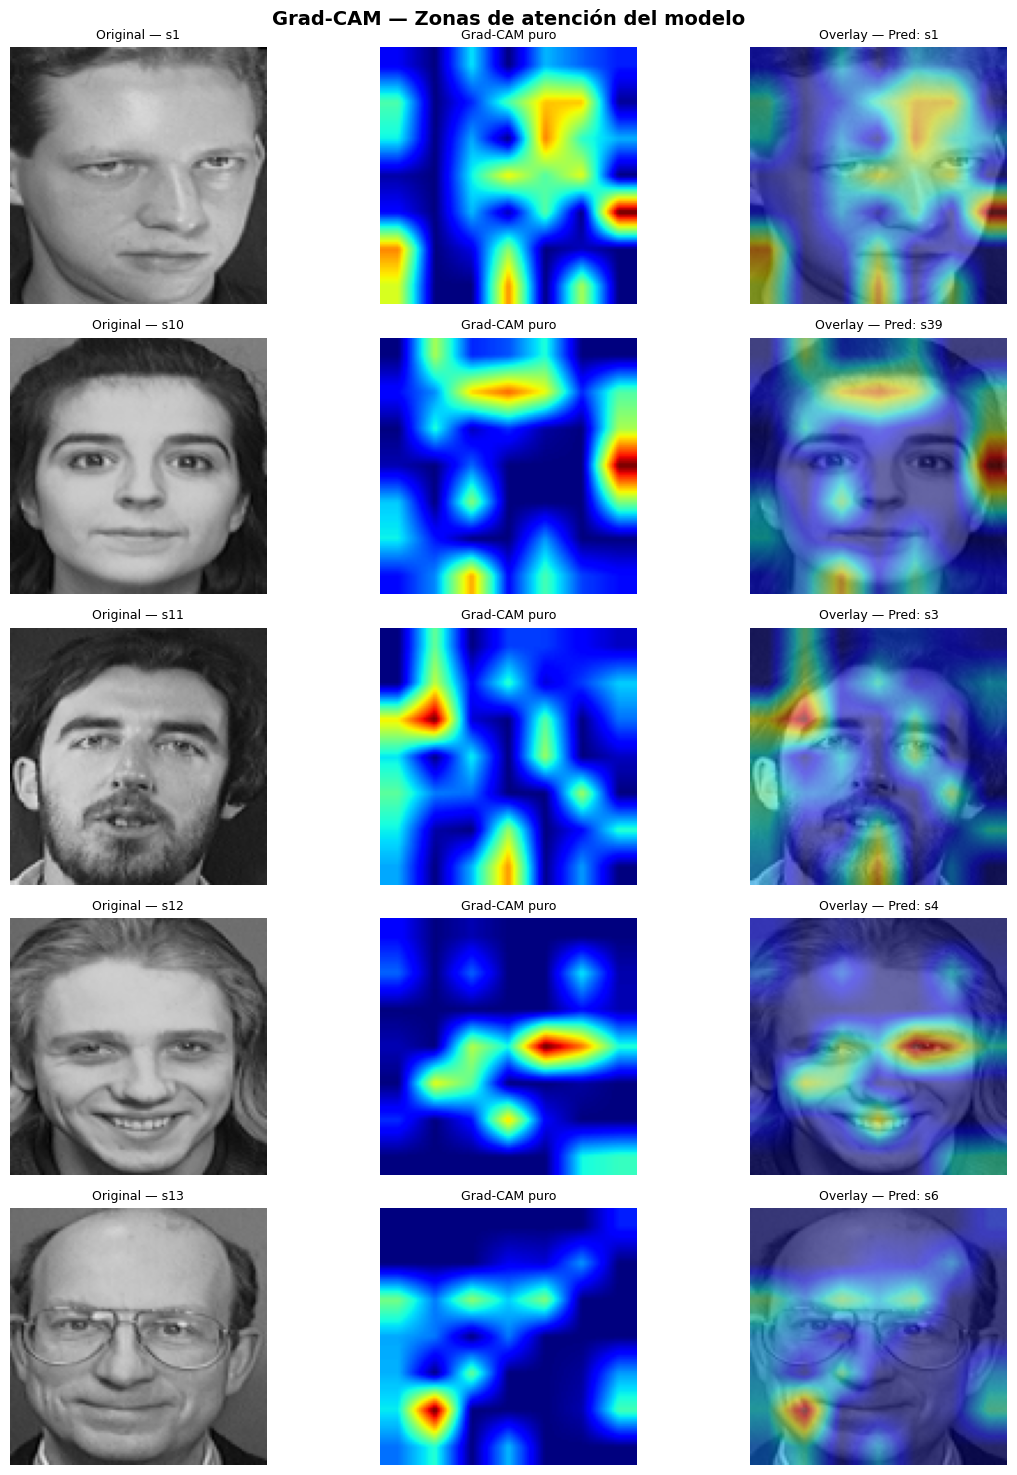

Grad-CAM guardado en gradcam_mobilefacenet.png


In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from PIL import Image
import os

# =====================================================
# GRAD-CAM
# =====================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.target_layer = target_layer
        self.gradients   = None
        self.activations = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Pesos promedio de los gradientes
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(112, 112), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def visualizar_gradcam(model, ruta_test, num_sujetos=5, device='cpu'):
    """Muestra Grad-CAM para imágenes originales vs degradadas"""

    # Capa objetivo — última capa del backbone
    target_layer = model.backbone.features[-2]  # última conv
    gradcam      = GradCAM(model, target_layer)

    transform = transforms.Compose([
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    sujetos = sorted([s for s in os.listdir(ruta_test)
                      if os.path.isdir(os.path.join(ruta_test, s))])[:num_sujetos]

    fig, axes = plt.subplots(num_sujetos, 3, figsize=(12, num_sujetos * 3))
    fig.suptitle('Grad-CAM — Zonas de atención del modelo', fontsize=14, fontweight='bold')

    for i, sujeto in enumerate(sujetos):
        carpeta = os.path.join(ruta_test, sujeto)
        archivos = sorted([f for f in os.listdir(carpeta)
                           if f.lower().endswith(('.png', '.pgm', '.jpg'))])
        if not archivos:
            continue

        img_path = os.path.join(carpeta, archivos[0])
        img_pil  = Image.open(img_path).convert('RGB')
        img_np   = np.array(img_pil.resize((112, 112)))

        input_tensor = transform(img_pil).unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)

        cam, pred = gradcam.generate(input_tensor)

        # Heatmap
        heatmap = plt.cm.jet(cam)[:, :, :3]
        overlay = 0.5 * img_np / 255.0 + 0.5 * heatmap

        axes[i, 0].imshow(img_np, cmap='gray' if img_np.mean() < 100 else None)
        axes[i, 0].set_title(f'Original — {sujeto}', fontsize=9)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(cam, cmap='jet')
        axes[i, 1].set_title(f'Grad-CAM puro', fontsize=9)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(f'Overlay — Pred: s{pred+1}', fontsize=9)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_mobilefacenet.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Grad-CAM guardado en gradcam_mobilefacenet.png")


# Cargar el mejor modelo (usa el que tenga mejor resultado — LR_x2)
backbone_viz = MobileFaceNetBackbone(embedding_size=128).to(device)
model_viz    = MobileFaceNetClassifier(backbone_viz, num_classes=40, freeze_backbone=False).to(device)
model_viz.load_state_dict(torch.load('mobilefacenet_LR_x2_fase3_best.pth', map_location=device))
model_viz.eval()

visualizar_gradcam(model_viz, ruta_test='dataset/Testing/', num_sujetos=5, device=device)

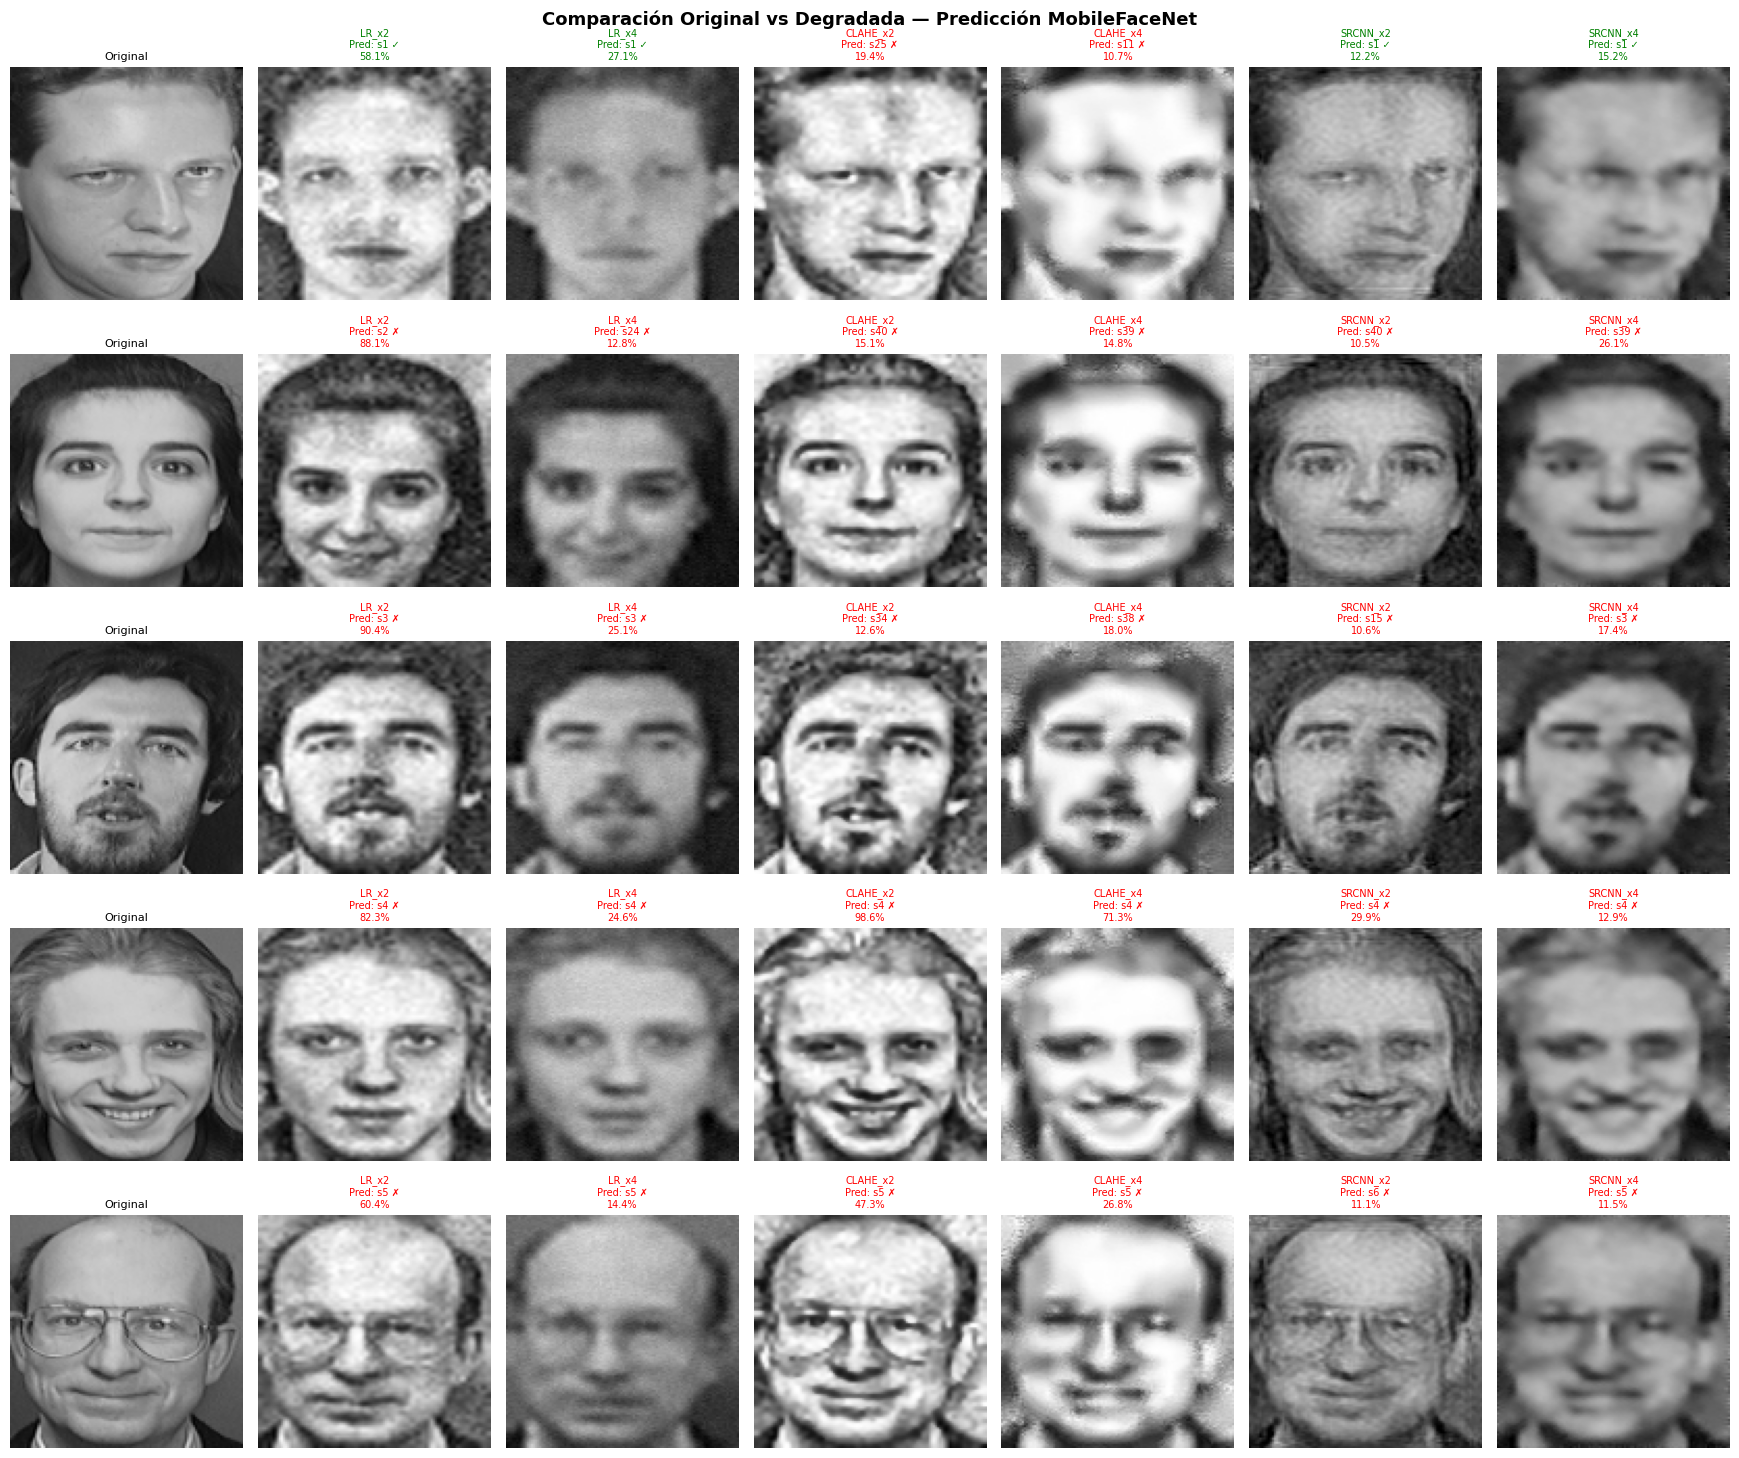

Comparación guardada en comparacion_predicciones.png


In [17]:
def comparar_original_vs_degradada(model, rutas_dict, ruta_original, num_sujetos=5, device='cpu'):
    """
    Muestra para cada sujeto:
    Original | LR_x2 | LR_x4 | CLAHE_x2 | CLAHE_x4 | SRCNN_x2 | SRCNN_x4
    Con la predicción del modelo debajo de cada imagen
    """
    transform = transforms.Compose([
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    sujetos = sorted([s for s in os.listdir(ruta_original)
                      if os.path.isdir(os.path.join(ruta_original, s))])[:num_sujetos]

    columnas  = ['Original'] + list(rutas_dict.keys())
    num_cols  = len(columnas)

    fig, axes = plt.subplots(num_sujetos, num_cols,
                             figsize=(num_cols * 2.5, num_sujetos * 3))
    fig.suptitle('Comparación Original vs Degradada — Predicción MobileFaceNet',
                 fontsize=13, fontweight='bold')

    for i, sujeto in enumerate(sujetos):
        label_real = int(sujeto[1:]) - 1  # s1 → 0, s2 → 1 ...

        # Columna 0 — imagen original
        ruta_img_orig = os.path.join(ruta_original, sujeto)
        arch_orig     = sorted([f for f in os.listdir(ruta_img_orig)
                                 if f.lower().endswith(('.png', '.pgm', '.jpg'))])[0]
        img_orig = Image.open(os.path.join(ruta_img_orig, arch_orig)).convert('RGB')
        axes[i, 0].imshow(img_orig.resize((112, 112)), cmap='gray')
        axes[i, 0].set_title('Original', fontsize=8)
        axes[i, 0].set_ylabel(f'{sujeto}', fontsize=9, fontweight='bold')
        axes[i, 0].axis('off')

        # Columnas 1-6 — versiones procesadas con predicción
        for j, (nombre, ruta) in enumerate(rutas_dict.items(), start=1):
            ruta_sujeto = os.path.join(ruta, sujeto)
            if not os.path.isdir(ruta_sujeto):
                axes[i, j].axis('off')
                continue

            archivos = sorted([f for f in os.listdir(ruta_sujeto)
                                if f.lower().endswith(('.png', '.pgm', '.jpg'))])
            if not archivos:
                axes[i, j].axis('off')
                continue

            img = Image.open(os.path.join(ruta_sujeto, archivos[0])).convert('RGB')

            # Predicción del modelo
            with torch.no_grad():
                tensor = transform(img).unsqueeze(0).to(device)
                output = model(tensor)
                pred   = output.argmax(dim=1).item()
                conf   = F.softmax(output, dim=1)[0, pred].item()

            correcto = (pred == label_real)
            color    = 'green' if correcto else 'red'
            simbolo  = '✓' if correcto else '✗'

            axes[i, j].imshow(img.resize((112, 112)), cmap='gray')
            axes[i, j].set_title(f'{nombre}\nPred: s{pred+1} {simbolo}\n{conf:.1%}',
                                  fontsize=7, color=color)
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.savefig('comparacion_predicciones.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Comparación guardada en comparacion_predicciones.png")


# Rutas de todas las versiones procesadas
RUTAS_VIZ = {
    'LR_x2':    'dataset/Training_LR_escala2/',
    'LR_x4':    'dataset/Training_LR_escala4/',
    'CLAHE_x2': 'dataset/CLAHE/Testing_CLAHE_escala2/',
    'CLAHE_x4': 'dataset/CLAHE/Testing_CLAHE_escala4/',
    'SRCNN_x2': 'dataset/Super_resolution/Testing_SR_escala2/',
    'SRCNN_x4': 'dataset/Super_resolution/Testing_SR_escala4/',
}

comparar_original_vs_degradada(
    model        = model_viz,
    rutas_dict   = RUTAS_VIZ,
    ruta_original= 'dataset/Testing/',
    num_sujetos  = 5,
    device       = device
)

In [19]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms


def generar_comparaciones_por_lotes(
        model,
        rutas_dict,
        ruta_original,
        output_dir="imagesMobilFaceNet",
        sujetos_por_imagen=5,
        device="cpu"
):

    os.makedirs(output_dir, exist_ok=True)

    transform = transforms.Compose([
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    sujetos = sorted([
        s for s in os.listdir(ruta_original)
        if os.path.isdir(os.path.join(ruta_original, s))
    ])

    total_sujetos = len(sujetos)
    columnas = ['Original'] + list(rutas_dict.keys())
    num_cols = len(columnas)

    for inicio in range(0, total_sujetos, sujetos_por_imagen):

        lote = sujetos[inicio:inicio + sujetos_por_imagen]

        fig, axes = plt.subplots(
            len(lote),
            num_cols,
            figsize=(num_cols * 2.8, len(lote) * 3.2)
        )

        if len(lote) == 1:
            axes = axes.reshape(1, -1)

        total_correctos = 0
        total_predicciones = 0

        for i, sujeto in enumerate(lote):

            label_real = int(sujeto[1:]) - 1

            # =====================================
            # ORIGINAL
            # =====================================
            ruta_suj_orig = os.path.join(ruta_original, sujeto)

            archivo_orig = sorted([
                f for f in os.listdir(ruta_suj_orig)
                if f.lower().endswith(
                    ('.png', '.jpg', '.jpeg', '.pgm')
                )
            ])[0]

            img_orig = Image.open(
                os.path.join(ruta_suj_orig, archivo_orig)
            ).convert("RGB")

            axes[i, 0].imshow(img_orig.resize((112, 112)))
            axes[i, 0].set_title(
                f"Original\n{sujeto}",
                fontsize=8,
                fontweight='bold'
            )
            axes[i, 0].axis("off")

            # =====================================
            # VERSIONES DEGRADADAS
            # =====================================
            for j, (nombre, ruta_proc) in enumerate(
                    rutas_dict.items(), start=1):

                ruta_suj_proc = os.path.join(
                    ruta_proc,
                    sujeto
                )

                if not os.path.isdir(ruta_suj_proc):
                    axes[i, j].axis("off")
                    continue

                archivos = sorted([
                    f for f in os.listdir(ruta_suj_proc)
                    if f.lower().endswith(
                        ('.png', '.jpg', '.jpeg', '.pgm')
                    )
                ])

                if len(archivos) == 0:
                    axes[i, j].axis("off")
                    continue

                ruta_img = os.path.join(
                    ruta_suj_proc,
                    archivos[0]
                )

                img = Image.open(
                    ruta_img
                ).convert("RGB")

                with torch.no_grad():

                    tensor = transform(img)\
                        .unsqueeze(0)\
                        .to(device)

                    output = model(tensor)

                    probs = F.softmax(
                        output,
                        dim=1
                    )

                    pred = output.argmax(1).item()

                    conf = probs[0, pred].item()

                correcto = (pred == label_real)

                total_predicciones += 1

                if correcto:
                    total_correctos += 1

                color = "green" if correcto else "red"
                simbolo = "✓" if correcto else "✗"

                axes[i, j].imshow(
                    img.resize((112, 112))
                )

                axes[i, j].set_title(
                    f"{nombre}\n"
                    f"Real: s{label_real+1}\n"
                    f"Pred: s{pred+1} {simbolo}\n"
                    f"Conf: {conf:.1%}",
                    fontsize=7,
                    color=color
                )

                axes[i, j].axis("off")

        acc_lote = (
            total_correctos / total_predicciones
            if total_predicciones > 0 else 0
        )

        fig.suptitle(
            f"MobileFaceNet | Sujetos {inicio+1}-{inicio+len(lote)}"
            f"\nAciertos: {total_correctos}/{total_predicciones}"
            f" | Accuracy lote: {acc_lote:.2%}",
            fontsize=13,
            fontweight='bold'
        )

        plt.tight_layout(rect=[0, 0, 1, 0.95])

        numero_archivo = (
            inicio // sujetos_por_imagen
        ) + 1

        ruta_salida = os.path.join(
            output_dir,
            f"comparacion_{numero_archivo:02d}.png"
        )

        plt.savefig(
            ruta_salida,
            dpi=200,
            bbox_inches='tight'
        )

        plt.close()

        print(
            f"[OK] Guardado: {ruta_salida}"
            f" | Acc lote = {acc_lote:.2%}"
        )

    print(
        f"\nProceso finalizado."
        f"\nImágenes guardadas en: {output_dir}"
    )

In [20]:
generar_comparaciones_por_lotes(
    model=model_viz,
    rutas_dict=RUTAS_VIZ,
    ruta_original='dataset/Testing/',
    output_dir='imagesMobilFaceNet',
    sujetos_por_imagen=5,
    device=device
)

[OK] Guardado: imagesMobilFaceNet\comparacion_01.png | Acc lote = 13.33%
[OK] Guardado: imagesMobilFaceNet\comparacion_02.png | Acc lote = 3.33%
[OK] Guardado: imagesMobilFaceNet\comparacion_03.png | Acc lote = 0.00%
[OK] Guardado: imagesMobilFaceNet\comparacion_04.png | Acc lote = 0.00%
[OK] Guardado: imagesMobilFaceNet\comparacion_05.png | Acc lote = 0.00%
[OK] Guardado: imagesMobilFaceNet\comparacion_06.png | Acc lote = 0.00%
[OK] Guardado: imagesMobilFaceNet\comparacion_07.png | Acc lote = 3.33%
[OK] Guardado: imagesMobilFaceNet\comparacion_08.png | Acc lote = 0.00%

Proceso finalizado.
Imágenes guardadas en: imagesMobilFaceNet


In [22]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from PIL import Image
from torchvision import transforms

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA


def visualizar_tsne_mobilefacenet(
        model,
        rutas_dict,
        device='cpu',
        output_file='tsne_mobilefacenet.png'
):

    transform = transforms.Compose([
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    model.eval()

    embeddings_por_combo = {}

    print("=" * 60)
    print("Extrayendo embeddings...")
    print("=" * 60)

    for nombre, ruta in rutas_dict.items():

        embeddings = []
        etiquetas = []

        sujetos = sorted([
            s for s in os.listdir(ruta)
            if os.path.isdir(os.path.join(ruta, s))
        ])

        for label, sujeto in enumerate(sujetos):

            carpeta = os.path.join(ruta, sujeto)

            archivos = sorted([
                f for f in os.listdir(carpeta)
                if f.lower().endswith(
                    ('.png', '.jpg', '.jpeg', '.pgm')
                )
            ])

            for archivo in archivos:

                ruta_img = os.path.join(
                    carpeta,
                    archivo
                )

                img = Image.open(
                    ruta_img
                ).convert('RGB')

                tensor = transform(img)\
                    .unsqueeze(0)\
                    .to(device)

                with torch.no_grad():

                    emb = model.backbone(tensor)

                    emb = emb.flatten(start_dim=1)

                embeddings.append(
                    emb.squeeze().cpu().numpy()
                )

                etiquetas.append(label)

        embeddings = np.array(embeddings)
        etiquetas = np.array(etiquetas)

        print(
            f"{nombre}: "
            f"{embeddings.shape[0]} muestras | "
            f"Dim = {embeddings.shape[1]}"
        )

        embeddings_por_combo[nombre] = (
            embeddings,
            etiquetas
        )

    print("\nGenerando t-SNE...")

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(20, 12)
    )

    axes = axes.flatten()

    colores = cm.get_cmap(
        'tab20',
        40
    )

    for idx, (nombre, datos) in enumerate(
            embeddings_por_combo.items()):

        embs, labs = datos

        print(f"\nProcesando {nombre}...")

        # =========================
        # PCA previo
        # =========================

        n_comp = min(
            50,
            embs.shape[1],
            embs.shape[0]-1
        )

        pca = PCA(
            n_components=n_comp,
            random_state=42
        )

        embs_pca = pca.fit_transform(embs)

        print(
            f"PCA: {embs.shape[1]} → "
            f"{embs_pca.shape[1]}"
        )

        # =========================
        # t-SNE
        # =========================

        tsne = TSNE(
            n_components=2,
            perplexity=15,
            max_iter=1000,
            random_state=42,
            init='pca'
        )

        embs_2d = tsne.fit_transform(
            embs_pca
        )

        # =========================
        # Graficar
        # =========================

        for clase in range(40):

            mask = labs == clase

            axes[idx].scatter(
                embs_2d[mask, 0],
                embs_2d[mask, 1],
                c=[colores(clase)],
                s=25,
                alpha=0.8
            )

        axes[idx].set_title(
            f'{nombre}',
            fontsize=12,
            fontweight='bold'
        )

        axes[idx].grid(
            alpha=0.3
        )

        axes[idx].set_xticks([])
        axes[idx].set_yticks([])

    plt.suptitle(
        'MobileFaceNet - Visualización t-SNE de Embeddings\n'
        '(40 sujetos, colores = identidades)',
        fontsize=16,
        fontweight='bold'
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    print("\nFigura guardada en:")
    print(output_file)

Extrayendo embeddings...
LR_x2: 360 muestras | Dim = 128
LR_x4: 360 muestras | Dim = 128
CLAHE_x2: 360 muestras | Dim = 128
CLAHE_x4: 360 muestras | Dim = 128
SRCNN_x2: 360 muestras | Dim = 128
SRCNN_x4: 360 muestras | Dim = 128

Generando t-SNE...

Procesando LR_x2...
PCA: 128 → 50

Procesando LR_x4...
PCA: 128 → 50

Procesando CLAHE_x2...
PCA: 128 → 50

Procesando CLAHE_x4...
PCA: 128 → 50

Procesando SRCNN_x2...
PCA: 128 → 50

Procesando SRCNN_x4...
PCA: 128 → 50


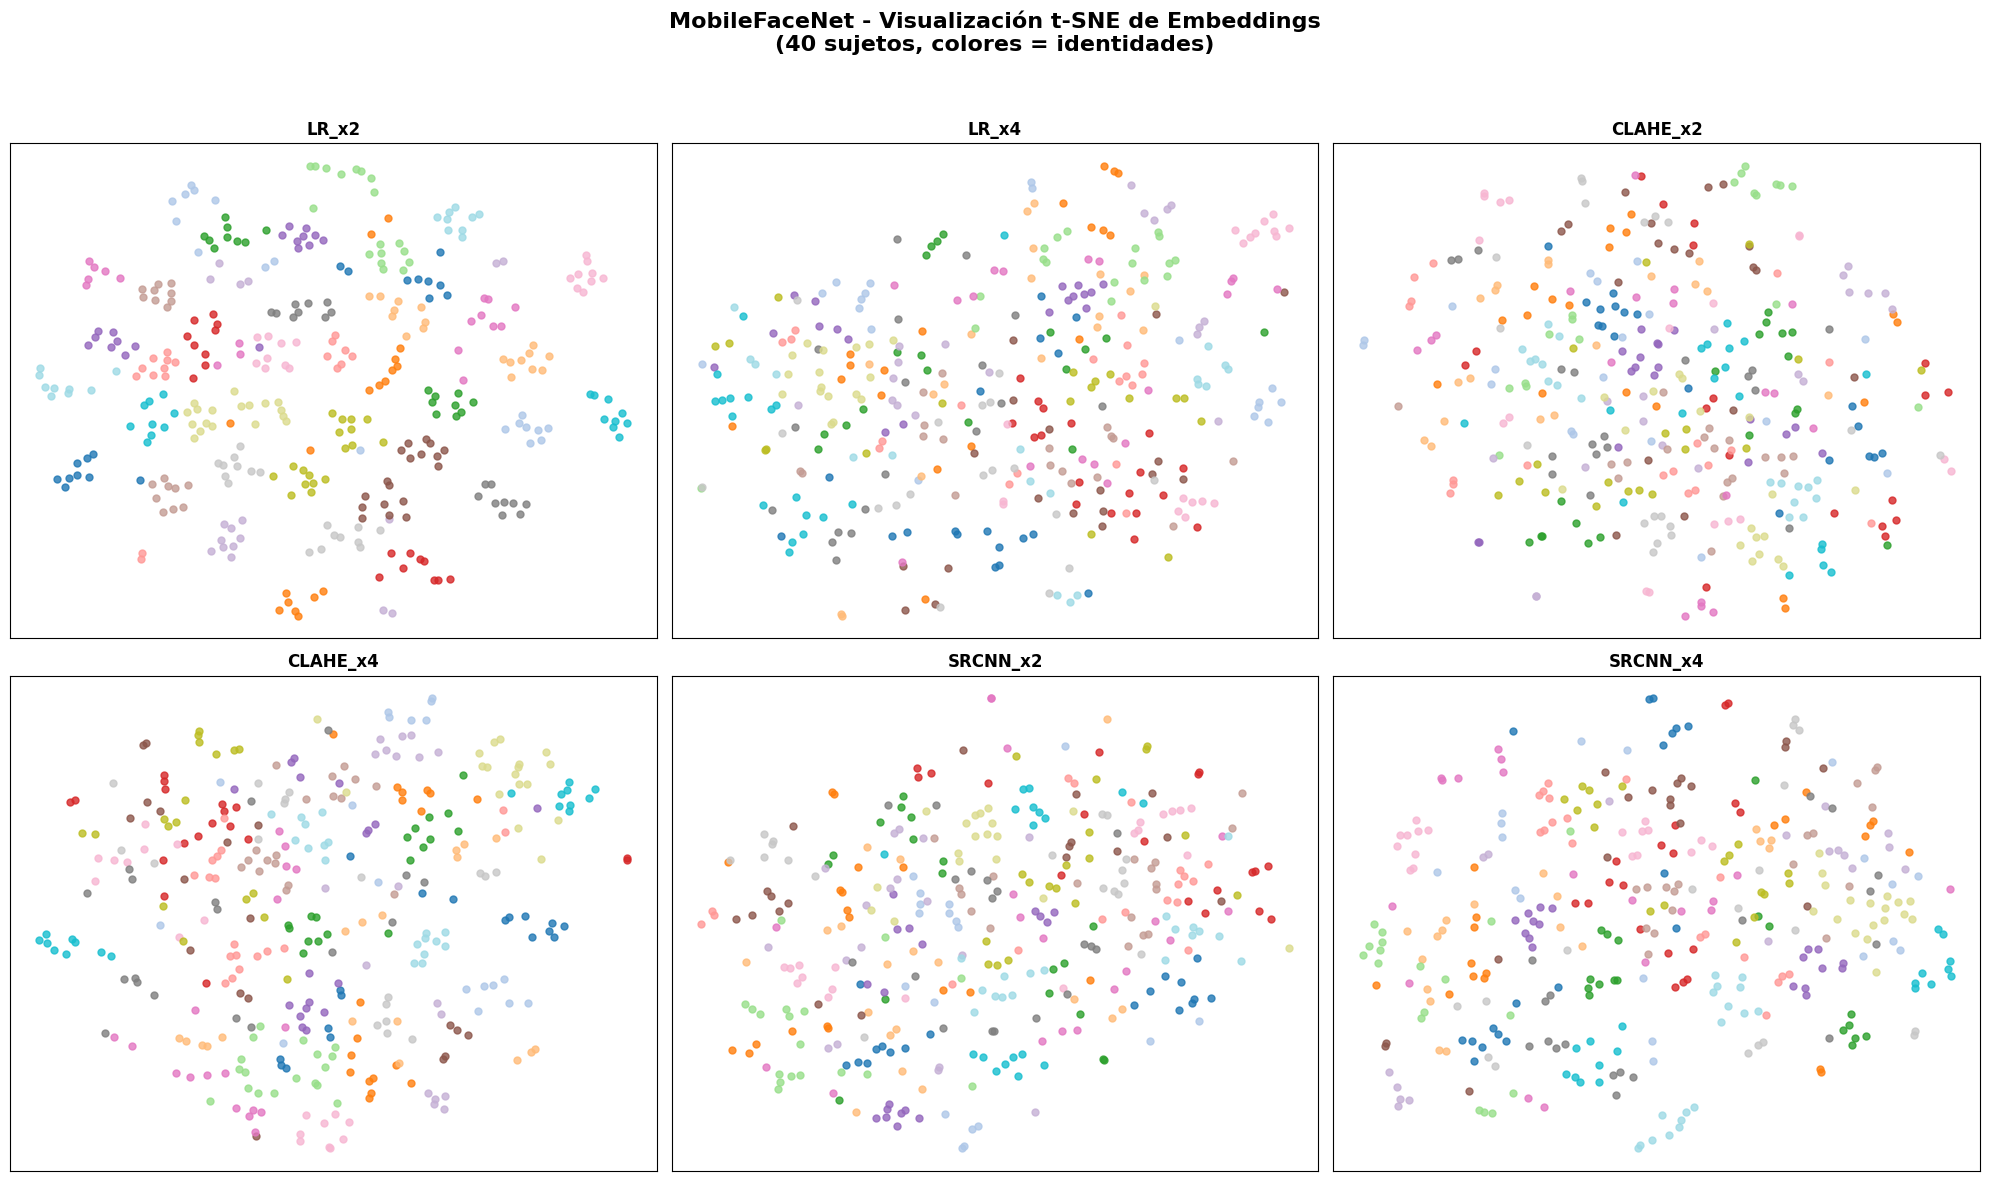


Figura guardada en:
tsne_mobilefacenet.png


In [23]:
RUTAS_TSNE = {
    'LR_x2':    'dataset/Training_LR_escala2/',
    'LR_x4':    'dataset/Training_LR_escala4/',
    'CLAHE_x2': 'dataset/CLAHE/Training_CLAHE_escala2/',
    'CLAHE_x4': 'dataset/CLAHE/Training_CLAHE_escala4/',
    'SRCNN_x2': 'dataset/Super_resolution/Training_SR_escala2/',
    'SRCNN_x4': 'dataset/Super_resolution/Training_SR_escala4/',
}

visualizar_tsne_mobilefacenet(
    model=model_viz,
    rutas_dict=RUTAS_TSNE,
    device=device,
    output_file='tsne_mobilefacenet.png'
)